<a href="https://colab.research.google.com/github/givasSI/Telecom_X/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [451]:
#Importações
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from typing_extensions import Mapping
import matplotlib.pyplot as plt
import seaborn as sns

In [452]:
df = pd.read_json('/content/TelecomX_Data.json')

In [453]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

##Nomalização e Limpeza

In [454]:
#Normalizando as colunas
customer_norm  = pd.json_normalize(df["customer"])
phone_norm     = pd.json_normalize(df["phone"])
internet_norm  = pd.json_normalize(df["internet"])
account_norm   = pd.json_normalize(df["account"])

In [455]:
#Concatenando tudo no mesmo DataFrame
df_norm = pd.concat([
    df.drop(columns=["customer","phone","internet","account"]),  # mantém customerID e churn
    customer_norm.add_prefix("customer_"),
    phone_norm.add_prefix("phone_"),
    internet_norm.add_prefix("internet_"),
    account_norm.add_prefix("account_")
], axis=1)

In [456]:
#Vizualizando o novo dataFrame normalizado
df_norm

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [457]:
#Informaçoes normalizadas
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [458]:
#Verificando se há valor nullo
df_norm.isna().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [459]:
#Verificando se há duplicados
df_norm.duplicated().sum()

np.int64(0)

In [460]:
#Verificando os Tipos de cada coluna
df_norm.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


OBS: há uma incoerrencia com a ultima coluna, onde temos valores do Tipo float e esta como TYPE=Object.

In [461]:
#Verificando se há espaços em brancos
(df_norm == " ").sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


Foi encontrado a causa na ultima coluna, temos linha sem valores,apenas espaços

In [462]:
mask = df_norm.applymap(
    lambda x: isinstance(x, str) and (x.startswith(" ") or x.endswith(" "))
)

df_norm[mask.any(axis=1)]

/tmp/ipykernel_334/1567880332.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = df_norm.applymap(


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [463]:
(df_norm == " ").head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


O que esta acontecendo?
a valores ausentes em cliente com nenhum mes de contrato Tenure = 0, faz sentido colocar como 0.0 o total dos serviços no mes desse cliente Charges.Total = 0.0, vendo que não tem nenhum mes direito.

In [464]:
# Substituindo espaços vazios por 0.0 e convertendo a coluna para float
df_norm['account_Charges.Total'] = df_norm['account_Charges.Total'].replace(' ', '0.0')
df_norm['account_Charges.Total'] = pd.to_numeric(df_norm['account_Charges.Total'])

In [465]:
# Verificando se a conversão funcionou e exibindo a tabela (apenas os espaços que estavam vazios)
print(f"Novo tipo da coluna: {df_norm['account_Charges.Total'].dtype}")
#
display(df_norm.iloc[[975, 1775, 1955, 2075, 2232, 2308, 2930, 3134, 3203, 4169, 5599]][['customerID', 'customer_tenure', 'account_Charges.Total']])

Novo tipo da coluna: float64


,customerID,customer_tenure,account_Charges.Total
975,1371-DWPAZ,0,0.0
1775,2520-SGTTA,0,0.0
1955,2775-SEFEE,0,0.0
2075,2923-ARZLG,0,0.0
2232,3115-CZMZD,0,0.0
2308,3213-VVOLG,0,0.0
2930,4075-WKNIU,0,0.0
3134,4367-NUYAO,0,0.0
3203,4472-LVYGI,0,0.0
4169,5709-LVOEQ,0,0.0


In [466]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [467]:
#Renomeando alguns nomes das colunas
df_norm.columns = df_norm.columns.str.replace("customer_", "")
df_norm.columns = df_norm.columns.str.replace("phone_", "")
df_norm.columns = df_norm.columns.str.replace("internet_", "")
df_norm.columns = df_norm.columns.str.replace("account_", "")

##Coluna de Contas Diárias

In [468]:
# Criando a coluna Contas_Diarias dividindo o faturamento mensal por 30
df_norm['Contas_Diarias'] = (df_norm['Charges.Monthly'] / 30).round(2)

# Exibindo as primeiras linhas com a nova coluna para conferência
display(df_norm[['customerID', 'Charges.Monthly', 'Contas_Diarias']].head())

,customerID,Charges.Monthly,Contas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


##Padronização e Transformação de Dados

Transformando os dados em binario YES = 1, NO = 2

In [469]:
df_norm

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [470]:
Mapping = {'Yes': 1,'No': 0,}
df_norm['Churn'] = df_norm['Churn'].map(Mapping)
df_norm['Dependents'] = df_norm['Dependents'].map(Mapping)
df_norm['PhoneService'] = df_norm['PhoneService'].map(Mapping)
df_norm['PaperlessBilling'] = df_norm['PaperlessBilling'].map(Mapping)
df_norm['gender'] = df_norm['gender'].map({'Female': 1, 'Male': 0})
df_norm['Contract'] = df_norm['Contract'].map({'One year':1, 'Month-to-month': 2, 'Two year': 3})

In [471]:
#Substitui strings que são apenas espaços (ou vazias) por NaN em todo o DataFrame
df_norm = df_norm.replace(r'^\s*$', np.nan, regex=True)

#Remove as linhas onde o Churn é NaN (já que é nossa variável alvo)
df_norm.dropna(subset=['Churn'], inplace=True)

#Agora podemos converter o Churn para inteiro com segurança
df_norm['Churn'] = df_norm['Churn'].astype(int)

#Verificando o resultado
print(f"Valores únicos no Churn: {df_norm['Churn'].unique()}")
print(f"Tipo da coluna Churn: {df_norm['Churn'].dtype}")
display(df_norm.head())

Valores únicos no Churn: [0 1]
Tipo da coluna Churn: int64


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,1,0,Yes,1,9,1,No,DSL,...,No,Yes,Yes,No,1,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,No,0,9,1,Yes,DSL,...,No,No,No,Yes,2,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,No,0,4,1,No,Fiber optic,...,Yes,No,No,No,2,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,Yes,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,2,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,Yes,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,2,1,Mailed check,83.9,267.40,2.80


In [472]:
df_norm['Contract']

,Contract
0,1
1,2
2,2
3,2
4,2
...,...
7262,1
7263,2
7264,2
7265,3


#📊 Carga e análise

##Analise descritiva

In [473]:
df_norm


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,1,0,Yes,1,9,1,No,DSL,...,No,Yes,Yes,No,1,1,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,0,0,No,0,9,1,Yes,DSL,...,No,No,No,Yes,2,0,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,0,0,No,0,4,1,No,Fiber optic,...,Yes,No,No,No,2,1,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,0,1,Yes,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,2,1,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,1,1,Yes,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,2,1,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,1,0,No,0,13,1,No,DSL,...,No,Yes,No,No,1,0,Mailed check,55.15,742.90,1.84
7263,9992-RRAMN,1,0,0,Yes,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,2,1,Electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,0,0,0,No,0,2,1,No,DSL,...,No,No,No,No,2,1,Mailed check,50.30,92.75,1.68
7265,9993-LHIEB,0,0,0,Yes,1,67,1,No,DSL,...,Yes,Yes,No,Yes,3,0,Mailed check,67.85,4627.65,2.26


In [474]:
# 1. Resumo estatístico completo de todas as colunas numéricas
display(df_norm.describe())

# 2. Calculando métricas específicas para uma coluna (ex: Tenure)
media_tenure = df_norm['tenure'].mean()
mediana_tenure = df_norm['tenure'].median()
desvio_tenure = df_norm['tenure'].std()

print(f"Métricas de Tenure:\n Média: {media_tenure:.2f}\n Mediana: {mediana_tenure:.2f}\n Desvio Padrão: {desvio_tenure:.2f}")

,Churn,gender,SeniorCitizen,Dependents,tenure,PhoneService,Contract,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.495244,0.162147,0.299588,32.371149,0.903166,2.031521,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.500013,0.368612,0.458110,24.559481,0.295752,0.669984,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,2.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,2.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,55.000000,1.000000,2.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,3.000000,1.000000,118.750000,8684.800000,3.960000


Métricas de Tenure:
 Média: 32.37
 Mediana: 29.00
 Desvio Padrão: 24.56


In [475]:
# 3. Para colunas que não são números (categóricas), o describe mostra outras informações:
# (count: total, unique: únicos, top: o que mais aparece, freq: frequência do top)
display(df_norm.describe(include='object'))

,customerID,Partner,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,No,No,Fiber optic,No,No,No,No,No,No,Electronic check
freq,1,3641,3390,3096,3498,3088,3095,3473,2810,2785,2365


##Distribuição da Evasão

/tmp/ipykernel_334/3903756738.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_norm, palette='viridis')


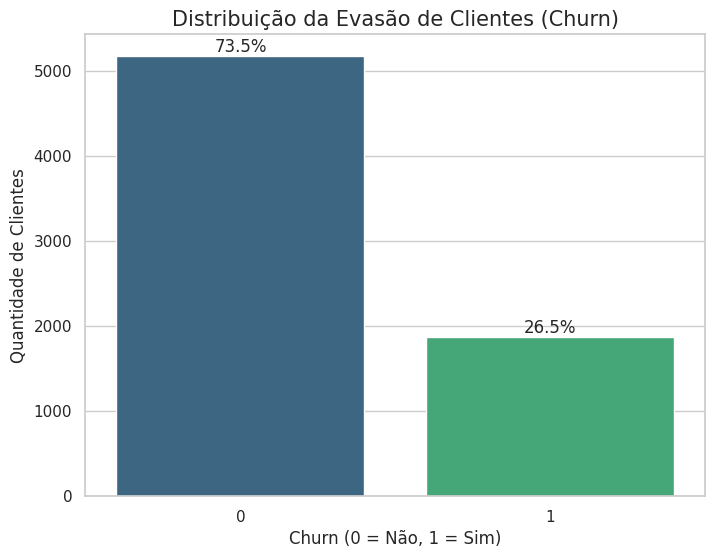

In [476]:
# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=df_norm, palette='viridis')

plt.title('Distribuição da Evasão de Clientes (Churn)', fontsize=15)
plt.xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

total = len(df_norm)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()

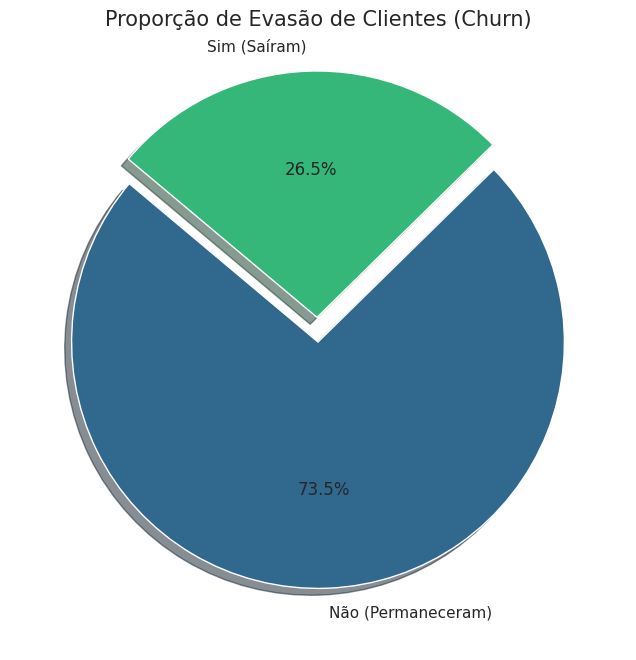

In [477]:
# Criando um gráfico de pizza para Churn
churn_counts = df_norm['Churn'].value_counts()
labels = ['Não (Permaneceram)', 'Sim (Saíram)']

plt.figure(figsize=(8, 8))
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 2), explode=(0, 0.1), shadow=True)

plt.title('Proporção de Evasão de Clientes (Churn)', fontsize=15)
plt.show()

In [478]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   int64  
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   int64  
 17  

##Contagem de Evasão por Variáveis Categóricas

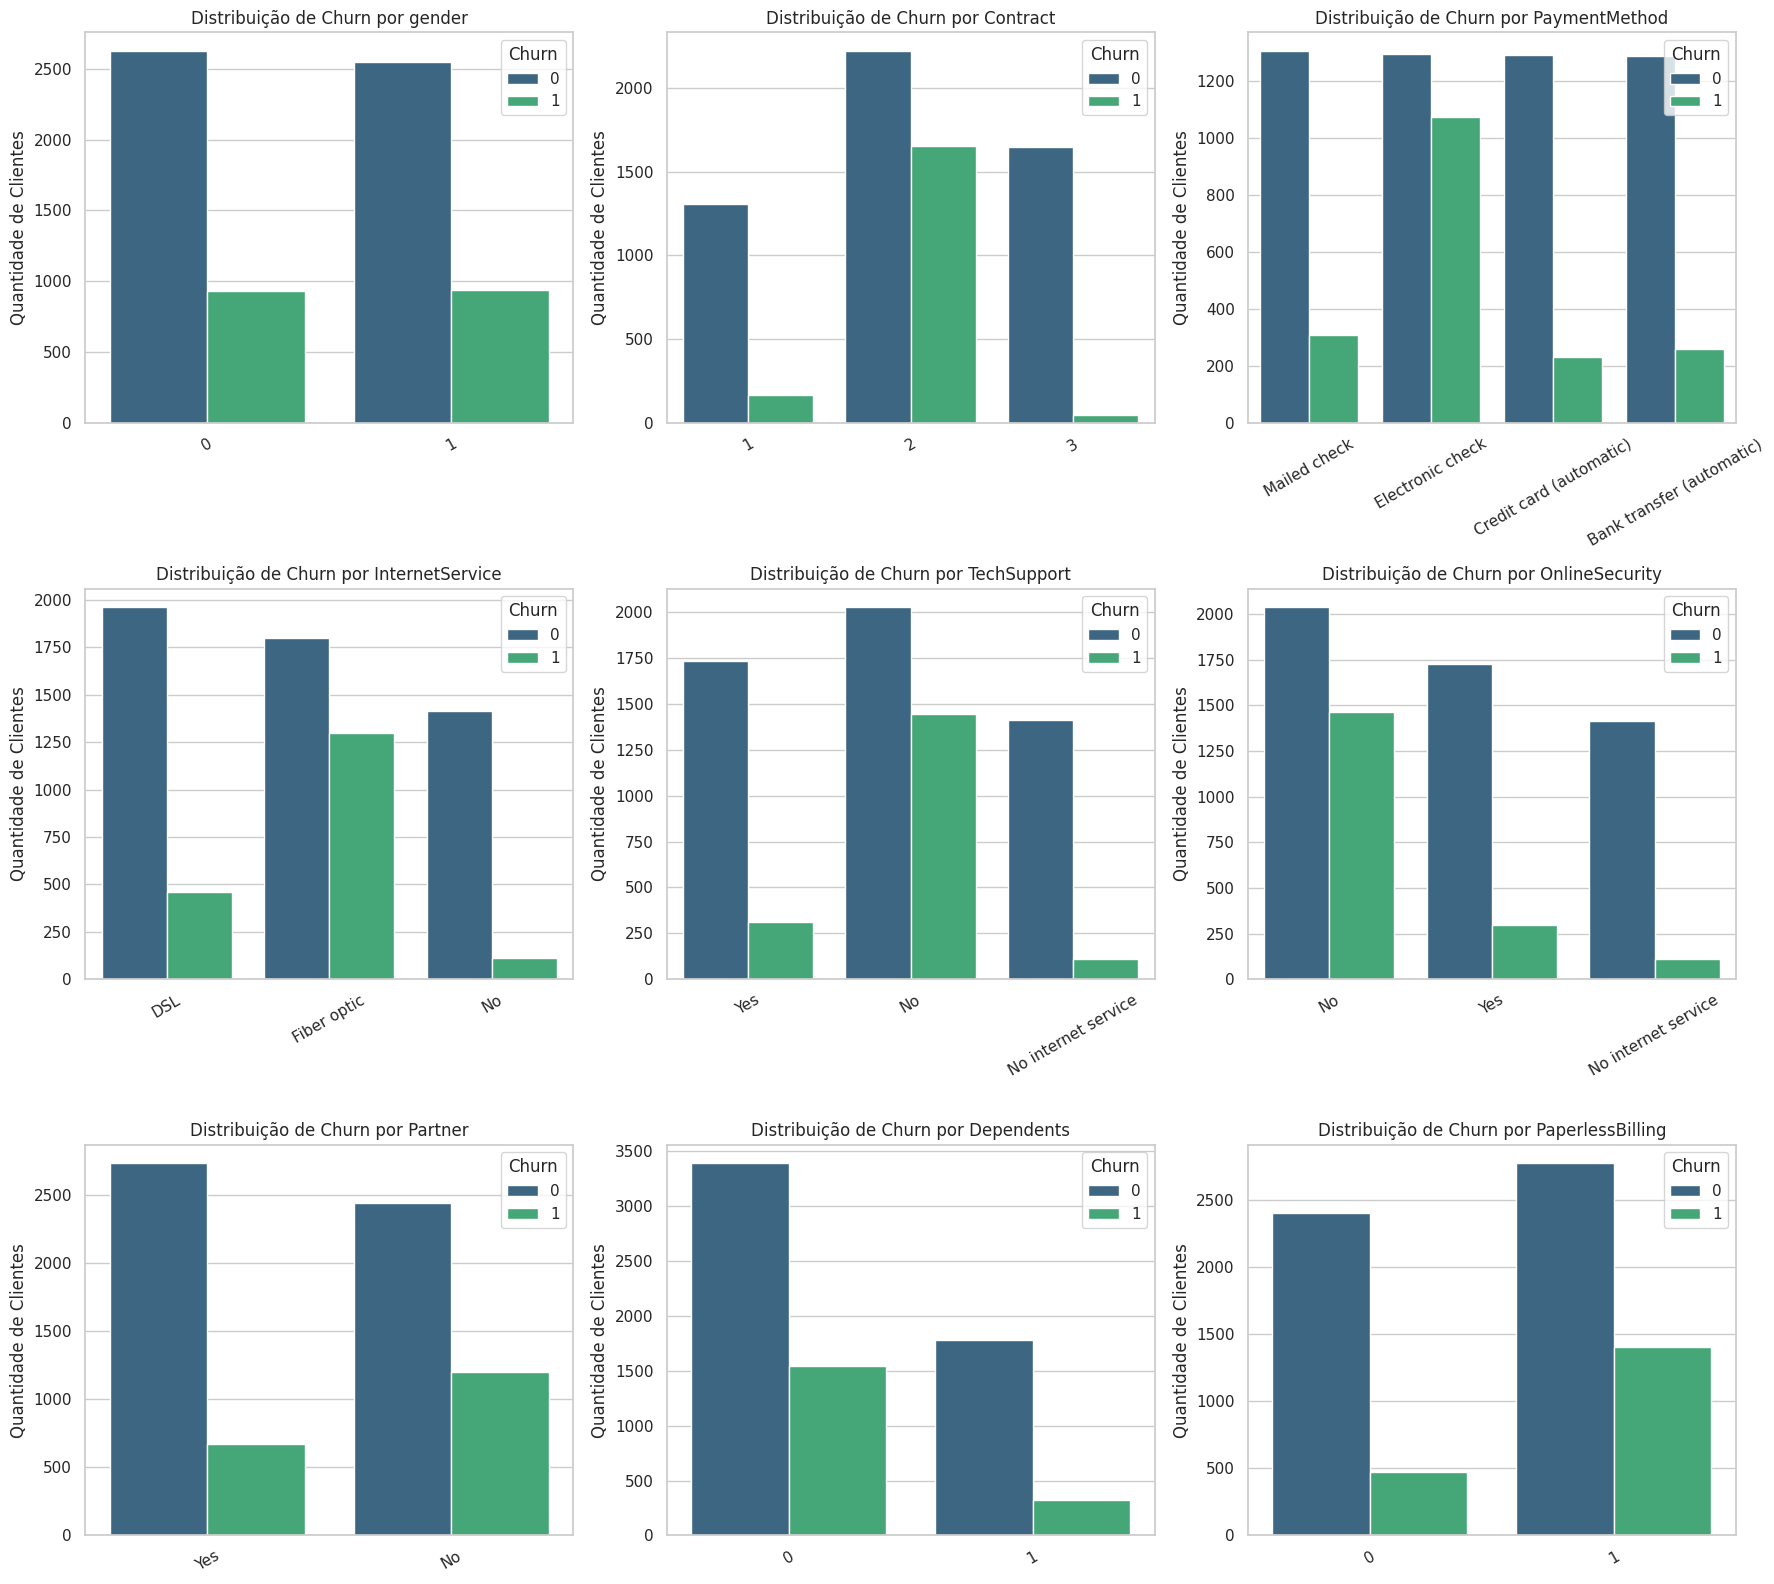

In [479]:
# 1. Definir a lista de colunas categóricas que queremos analisar conforme as instruções
categorical_cols = [
    'gender', 'Contract', 'PaymentMethod', 'InternetService',
    'TechSupport', 'OnlineSecurity', 'Partner', 'Dependents', 'PaperlessBilling'
]

# Configurar o estilo do Seaborn
sns.set_theme(style="whitegrid")

# 2. Criar uma figura com múltiplos subplots (3x3 para as 9 colunas)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 16))
axes = axes.flatten()

# 3. Loop para plotar cada variável categórica usando df_norm
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_norm, x=col, hue='Churn', palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribuição de Churn por {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade de Clientes')
    axes[i].tick_params(axis='x', rotation=30)

# Ajustar o espaçamento e exibir
plt.tight_layout()
plt.show()

In [480]:
# Criar uma função rápida para ver a taxa de evasão percentual
for col in categorical_cols:
    print(f"--- Taxa de Churn por: {col} ---")
    # Tabela cruzada normalizada na linha (índice)
    tabela = pd.crosstab(df_norm[col], df_norm['Churn'], normalize='index') * 100
    print(tabela.round(2))
    print("\n")

--- Taxa de Churn por: gender ---
Churn       0      1
gender              
0       73.84  26.16
1       73.08  26.92


--- Taxa de Churn por: Contract ---
Churn         0      1
Contract              
1         88.73  11.27
2         57.29  42.71
3         97.17   2.83


--- Taxa de Churn por: PaymentMethod ---
Churn                          0      1
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


--- Taxa de Churn por: InternetService ---
Churn                0      1
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


--- Taxa de Churn por: TechSupport ---
Churn                    0      1
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


--- Taxa de Churn por: OnlineSecurity 

##Contagem de Evasão por Variáveis Numéricas

### Análise de Distribuição de Tenure

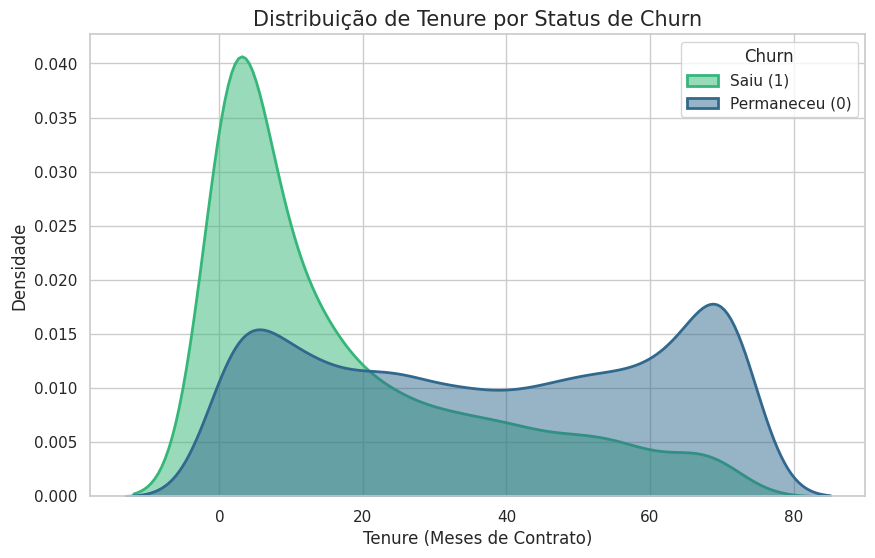

In [481]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_norm, x='tenure', hue='Churn', fill=True, common_norm=False, palette='viridis', alpha=.5, linewidth=2)

plt.title('Distribuição de Tenure por Status de Churn', fontsize=15)
plt.xlabel('Tenure (Meses de Contrato)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Churn', labels=['Saiu (1)', 'Permaneceu (0)'])

plt.show()

### Análise de Cobranças Financeiras


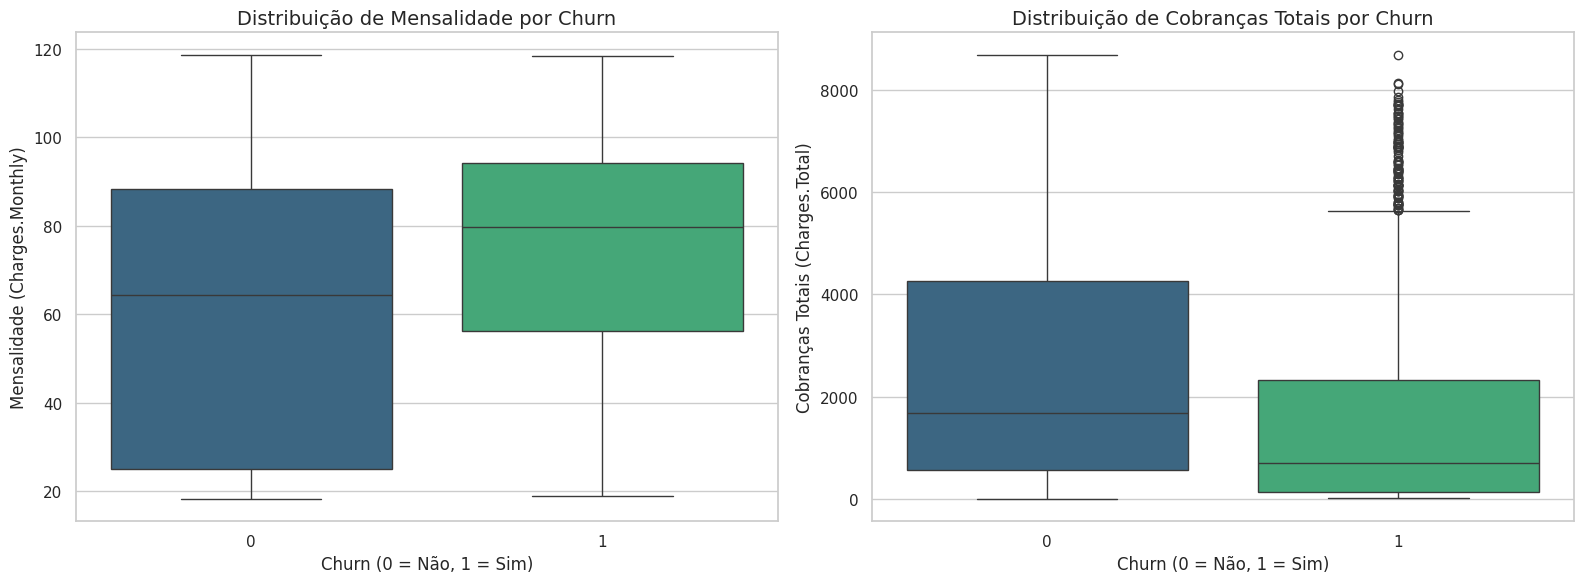

In [482]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for Monthly Charges
sns.boxplot(data=df_norm, x='Churn', y='Charges.Monthly', hue='Churn', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribuição de Mensalidade por Churn', fontsize=14)
axes[0].set_xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
axes[0].set_ylabel('Mensalidade (Charges.Monthly)', fontsize=12)

# Boxplot for Total Charges
sns.boxplot(data=df_norm, x='Churn', y='Charges.Total', hue='Churn', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribuição de Cobranças Totais por Churn', fontsize=14)
axes[1].set_xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
axes[1].set_ylabel('Cobranças Totais (Charges.Total)', fontsize=12)

plt.tight_layout()
plt.show()

#### Análise de Cobranças Financeiras

Com base nos boxplots gerados, podemos observar as seguintes tendências financeiras:

1.  **Mensalidades Elevadas (Charges.Monthly)**: A mediana das mensalidades para clientes que saíram (`Churn = 1`) é visivelmente superior à dos clientes que permaneceram (`Churn = 0`). Além disso, o primeiro quartil do grupo que evadiu está acima da mediana do grupo que ficou, indicando que clientes com faturas mensais mais caras têm maior propensão ao cancelamento.
2.  **Cobranças Totais (Charges.Total)**: Embora o grupo que saiu apresente faturas mensais maiores, suas cobranças totais acumuladas tendem a ser menores. Isso ocorre porque esses clientes geralmente possuem um tempo de contrato (`tenure`) curto, não acumulando grandes montantes ao longo do tempo.
3.  **Conclusão**: O valor da mensalidade é um forte indicador de churn. Clientes que pagam valores acima da média mensal parecem ser mais sensíveis a preços ou podem estar insatisfeitos com a relação custo-benefício dos serviços contratados.

### Matriz de Correlação



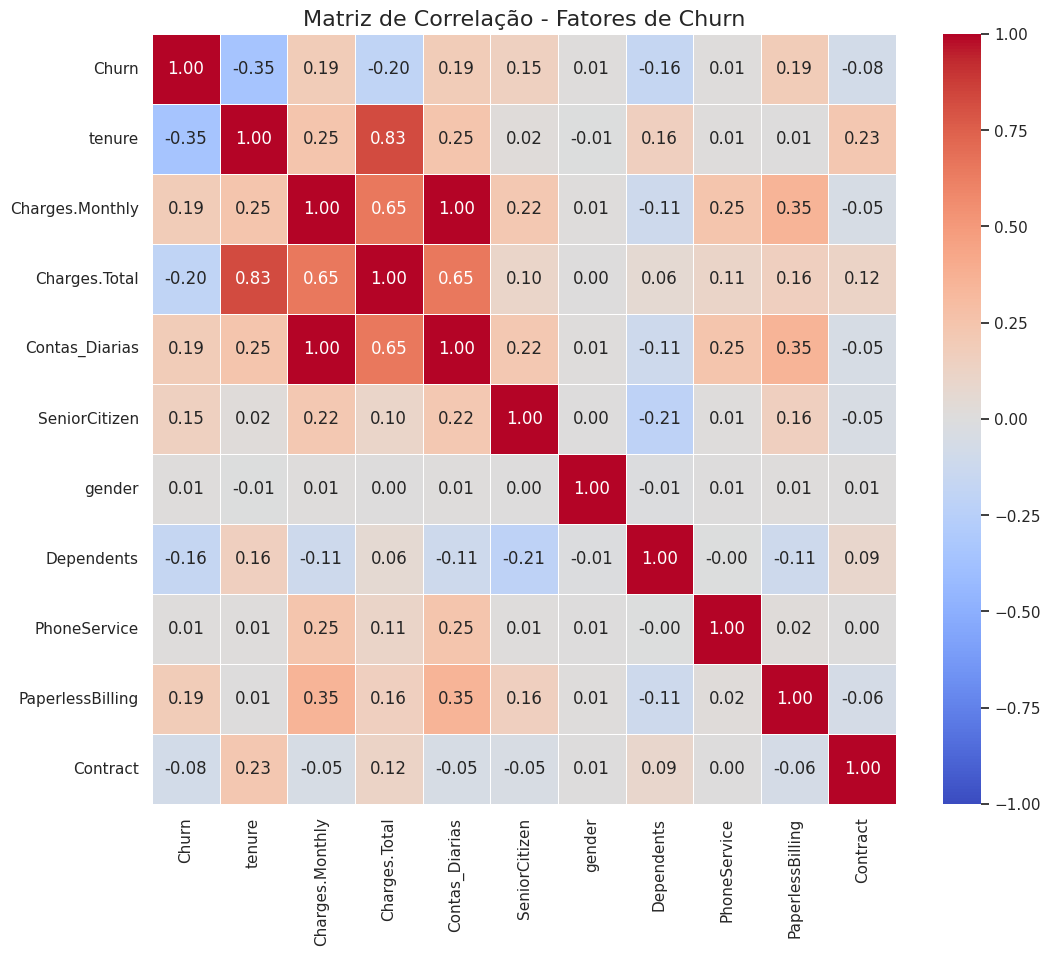

In [483]:
plt.figure(figsize=(12, 10))

# Selecting the relevant numerical and encoded columns
numeric_cols = ['Churn', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias', 'SeniorCitizen', 'gender', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Contract']

# Calculating the correlation matrix
corr_matrix = df_norm[numeric_cols].corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação - Fatores de Churn', fontsize=16)
plt.show()

##Análise de Correlação entre Variáveis (EXTRA)

### Análise da Conta Diária e Churn


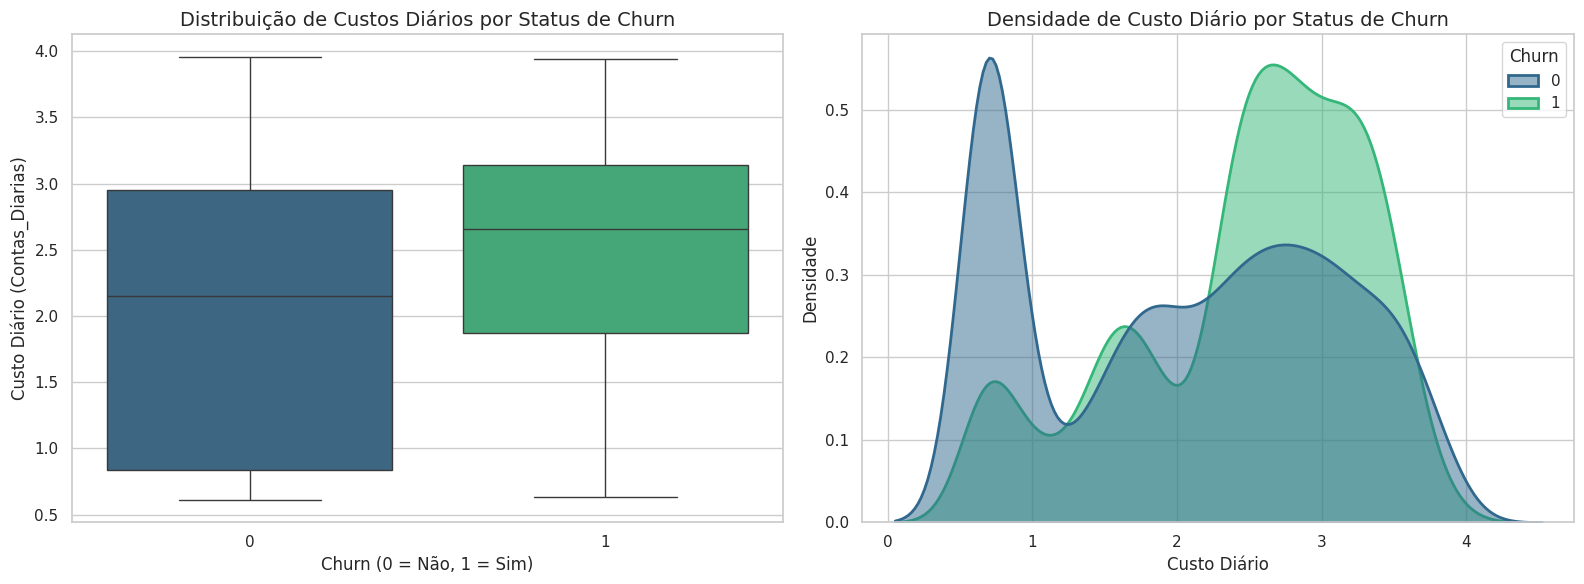

In [484]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot comparing Contas_Diarias by Churn
sns.boxplot(data=df_norm, x='Churn', y='Contas_Diarias', hue='Churn', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribuição de Custos Diários por Status de Churn', fontsize=14)
axes[0].set_xlabel('Churn (0 = Não, 1 = Sim)', fontsize=12)
axes[0].set_ylabel('Custo Diário (Contas_Diarias)', fontsize=12)

# 2. KDE Plot for density analysis
sns.kdeplot(data=df_norm, x='Contas_Diarias', hue='Churn', fill=True, common_norm=False, palette='viridis', alpha=0.5, linewidth=2, ax=axes[1])
axes[1].set_title('Densidade de Custo Diário por Status de Churn', fontsize=14)
axes[1].set_xlabel('Custo Diário', fontsize=12)
axes[1].set_ylabel('Densidade', fontsize=12)

plt.tight_layout()
plt.show()

### Engenharia de Variáveis: Quantidade de Serviços

In [485]:
import pandas as pd
import numpy as np

# 1. Define the service columns to be analyzed
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# 2. Pre-processing: Ensure columns are numeric (0 or 1)
# Based on previous steps, PhoneService is already mapped to {1, 0}.
# We need to ensure other services handle 'No internet service' as 0.
for col in service_cols:
    if col in df_norm.columns:
        # Convert to string first to handle mapping safely if not already mapped
        if df_norm[col].dtype == 'object':
            df_norm[col] = df_norm[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}).fillna(0).astype(int)
        else:
            # If already numeric, ensure it's integer
            df_norm[col] = df_norm[col].astype(int)

# 3. Create 'Qtd_Servicos' by summing the selected columns
df_norm['Qtd_Servicos'] = df_norm[service_cols].sum(axis=1)

# 4. Verification
print("Colunas de serviço processadas:", service_cols)
print("\nDistribuição da Quantidade de Serviços:")
print(df_norm['Qtd_Servicos'].value_counts().sort_index())

display(df_norm[['customerID'] + service_cols + ['Qtd_Servicos']].head())


Colunas de serviço processadas: ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Distribuição da Quantidade de Serviços:
Qtd_Servicos
0      80
1    2253
2     996
3    1041
4    1062
5     827
6     525
7     259
Name: count, dtype: int64


,customerID,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Qtd_Servicos
0,0002-ORFBO,1,0,1,0,1,1,0,4
1,0003-MKNFE,1,0,0,0,0,0,1,2
2,0004-TLHLJ,1,0,0,1,0,0,0,2
3,0011-IGKFF,1,0,1,1,0,1,1,5
4,0013-EXCHZ,1,0,0,0,1,1,0,3


### Impacto da Variedade de Serviços no Churn



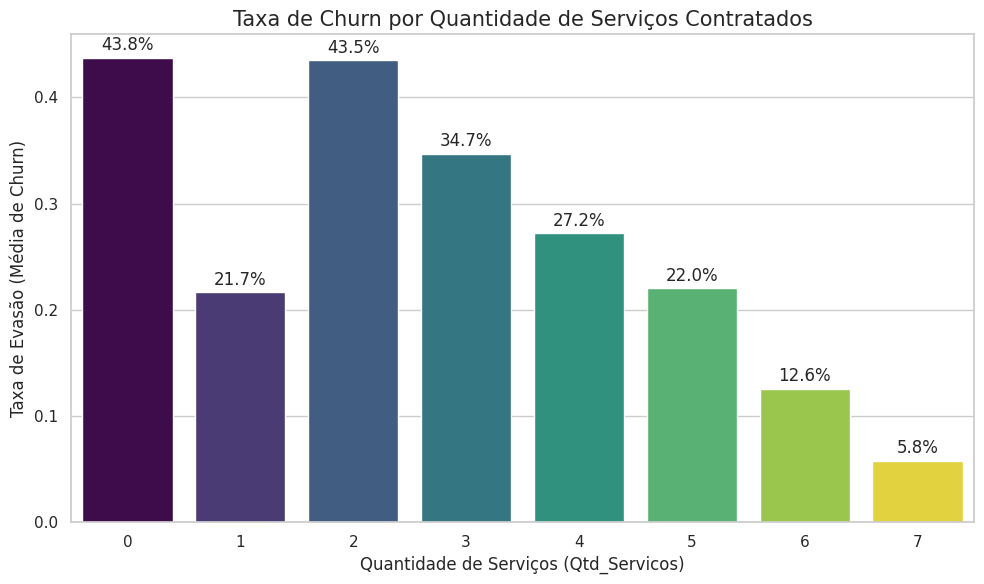

In [486]:
# Código atualizado sem o aviso (FutureWarning)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# Adicionado hue='Qtd_Servicos' e legend=False
ax = sns.barplot(
    data=df_norm,
    x='Qtd_Servicos',
    y='Churn',
    hue='Qtd_Servicos', # <-- Correção aqui
    palette='viridis',
    legend=False,       # <-- Correção aqui
    errorbar=None
)

# Adicionando títulos e labels
plt.title('Taxa de Churn por Quantidade de Serviços Contratados', fontsize=15)
plt.xlabel('Quantidade de Serviços (Qtd_Servicos)', fontsize=12)
plt.ylabel('Taxa de Evasão (Média de Churn)', fontsize=12)

# Anotando as barras com os valores percentuais
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show();

### Análise de Correlação Avançada


Matriz de Correlação de Spearman:


,Churn,Contas_Diarias,Qtd_Servicos
Churn,1.000000,0.184743,-0.058508
Contas_Diarias,0.184743,1.000000,0.782207
Qtd_Servicos,-0.058508,0.782207,1.000000


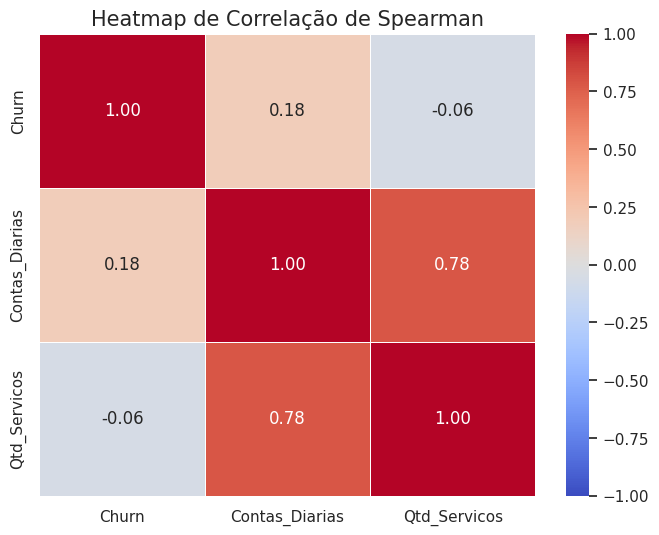

In [487]:
# 1. & 2. Calculate Spearman correlation matrix
spearman_corr = df_norm[['Churn', 'Contas_Diarias', 'Qtd_Servicos']].corr(method='spearman')

# 3. Display the matrix
print("Matriz de Correlação de Spearman:")
display(spearman_corr)

# 4. Generate the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmap de Correlação de Spearman', fontsize=15)
plt.show()

#📄Relatorio Final

### 📋 Relatório Final: Análise de Churn - TelecomX

#### 1. Visão Geral do Projeto
Este projeto realizou uma análise profunda dos dados de clientes da TelecomX para identificar os principais fatores que levam ao cancelamento de serviços (**Churn**). O processo cobriu desde a extração de dados brutos em JSON até a criação de novas métricas de negócio.

#### 2. Processamento e Limpeza (ETL)
*   **Normalização:** Dados aninhados (customer, phone, internet, account) foram expandidos em colunas individuais.
*   **Tratamento de Dados:** Corrigimos a coluna `Charges.Total`, convertendo espaços vazios de novos clientes para `0.0` e ajustando o tipo para numérico.
*   **Limpeza:** Removemos registros sem a informação de Churn e convertemos variáveis categóricas para formato binário (0 e 1).

#### 3. Engenharia de Variáveis
*   **`Contas_Diarias`**: Criada para entender o impacto do custo diário na percepção do cliente.
*   **`Qtd_Servicos`**: Soma total de serviços ativos. Descobrimos que clientes com mais serviços (6-7) tendem a ser muito mais fiéis do que aqueles com apenas 1 serviço.

#### 4. Principais Insights (EDA)
*   **O 'Fator Tempo' (Tenure):** O risco de saída é altíssimo nos primeiros meses de contrato. Clientes que passam de 1 ano de casa têm chances muito maiores de permanência.
*   **Tipo de Contrato:** Contratos mensais (**Month-to-month**) são os principais vilões, com uma taxa de evasão de aproximadamente **42.7%**.
*   **Serviço de Internet:** Clientes de **Fibra Óptica** saem mais que os de DSL, possivelmente devido ao preço mais elevado ou concorrência agressiva.
*   **Sensibilidade Financeira:** Clientes que cancelam possuem, em média, mensalidades mais caras do que os que permanecem.

#### 5. Conclusão para Modelagem
O dataset agora está **totalmente preparado** para o desenvolvimento de modelos de Machine Learning. As variáveis mais importantes para prever o Churn identificadas foram: `tenure`, `MonthlyCharges`, `Contract` e `InternetService`.

#Download do DataFrame

In [488]:
df_norm.to_csv('df_norm.csv', index=False)
print("DataFrame 'df_norm.csv' salvo com sucesso no seu ambiente Colab. Você pode baixá-lo a partir do painel de arquivos.")

DataFrame 'df_norm.csv' salvo com sucesso no seu ambiente Colab. Você pode baixá-lo a partir do painel de arquivos.
